In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
#load data
df = pd.read_csv('portugal_listinigs.csv')
df.head()

/var/folders/71/39zhsx8n3pzc596t6bw34mlc0000gn/T/ipykernel_48663/2433234493.py:2: DtypeWarning: Columns (6,8,12,13,14,15,16,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('portugal_listinigs.csv')


,Price,District,City,Town,Type,EnergyCertificate,Floor,Parking,HasParking,ConstructionYear,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
0,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,2nd Floor,1.0,True,NaN,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,2.0
1,9500.0,Faro,Albufeira,Albufeira e Olhos de Água,Apartment,NC,1st Floor,0.0,False,1990.0,...,True,NaN,0.0,NaN,NaN,NaN,27.0,NaN,NaN,1.0
2,580000.0,Faro,Vila do Bispo,Budens,Apartment,D,3rd Floor,1.0,True,2003.0,...,False,NaN,2.0,NaN,NaN,NaN,84.0,NaN,NaN,2.0
3,350000.0,Faro,Portimão,Portimão,Apartment,C,4th Floor,0.0,False,1985.0,...,True,NaN,2.0,NaN,NaN,NaN,68.0,NaN,NaN,1.0
4,175000.0,Faro,Faro,Faro (Sé e São Pedro),House,NC,NaN,0.0,False,1950.0,...,False,NaN,4.0,NaN,NaN,NaN,78.0,NaN,NaN,2.0


In [3]:
# Dataframe summary

def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Type'])
    summ['Missing#'] = df.isna().sum()
    summ['Missing%'] = (df.isna().sum())/len(df)
    summ['Dups'] = df.duplicated().sum()
    summ['Uniques'] = df.nunique().values
    summ['Count'] = df.count().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['Min'] = desc['min'].values
    summ['Max'] = desc['max'].values
    summ['Average'] = desc['mean'].values
    summ['Standard Deviation'] = desc['std'].values
    summ['First Value'] = df.loc[0].values
    summ['Second Value'] = df.loc[1].values
    summ['Third Value'] = df.loc[2].values

    display(summ)

summary(df)

data shape: (120826, 25)


,Data Type,Missing#,Missing%,Dups,Uniques,Count,Min,Max,Average,Standard Deviation,First Value,Second Value,Third Value
Price,float64,281,0.002326,6941,4455,120545,1.0,1380000000.0,367465.780519,4024605.83297,250000.0,9500.0,580000.0
District,object,0,0.000000,6941,25,120826,NaN,NaN,NaN,NaN,Faro,Faro,Faro
City,object,0,0.000000,6941,272,120826,NaN,NaN,NaN,NaN,São Brás de Alportel,Albufeira,Vila do Bispo
Town,object,2,0.000017,6941,2246,120824,NaN,NaN,NaN,NaN,São Brás de Alportel,Albufeira e Olhos de Água,Budens
Type,object,16,0.000132,6941,21,120810,NaN,NaN,NaN,NaN,Apartment,Apartment,Apartment
EnergyCertificate,object,14,0.000116,6941,12,120812,NaN,NaN,NaN,NaN,A+,NC,D
Floor,object,92897,0.768849,6941,19,27929,NaN,NaN,NaN,NaN,2nd Floor,1st Floor,3rd Floor
Parking,float64,194,0.001606,6941,4,120632,0.0,3.0,0.57052,0.870374,1.0,0.0,1.0
HasParking,object,52611,0.435428,6941,2,68215,NaN,NaN,NaN,NaN,True,False,True
ConstructionYear,float64,42598,0.352557,6941,123,78228,1900.0,2024.0,1988.993596,26.690061,NaN,1990.0,2003.0


### Missing Values

In [4]:
# select features with more than 50% missing values
missing = df.isnull().sum()/len(df)
missing = missing[missing > 0.5]
missing.sort_values(inplace=True)
missing

# drop 
df.drop(columns=missing.index, inplace=True)
df.head()


,Price,District,City,Town,Type,EnergyCertificate,Parking,HasParking,ConstructionYear,TotalArea,Elevator,TotalRooms,LivingArea,NumberOfBathrooms
0,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,1.0,True,NaN,114.0,True,2.0,114.0,2.0
1,9500.0,Faro,Albufeira,Albufeira e Olhos de Água,Apartment,NC,0.0,False,1990.0,27.0,True,0.0,27.0,1.0
2,580000.0,Faro,Vila do Bispo,Budens,Apartment,D,1.0,True,2003.0,84.0,False,2.0,84.0,2.0
3,350000.0,Faro,Portimão,Portimão,Apartment,C,0.0,False,1985.0,68.0,True,2.0,68.0,1.0
4,175000.0,Faro,Faro,Faro (Sé e São Pedro),House,NC,0.0,False,1950.0,78.0,False,4.0,78.0,2.0


### Check duplicates

In [5]:
#check  duplicates
df.duplicated().sum()

# drop duplicates
df.drop_duplicates(inplace=True)

In [6]:
# Dataframe summary

def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Type'])
    summ['Missing#'] = df.isna().sum()
    summ['Missing%'] = (df.isna().sum())/len(df)
    summ['Dups'] = df.duplicated().sum()
    summ['Uniques'] = df.nunique().values
    summ['Count'] = df.count().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['Min'] = desc['min'].values
    summ['Max'] = desc['max'].values
    summ['Average'] = desc['mean'].values
    summ['Standard Deviation'] = desc['std'].values
    summ['First Value'] = df.loc[0].values
    summ['Second Value'] = df.loc[1].values
    summ['Third Value'] = df.loc[2].values

    display(summ)

summary(df)

data shape: (111576, 14)


,Data Type,Missing#,Missing%,Dups,Uniques,Count,Min,Max,Average,Standard Deviation,First Value,Second Value,Third Value
Price,float64,232,0.002079,0,4455,111344,1.0,1380000000.0,370555.063648,4185798.545395,250000.0,9500.0,580000.0
District,object,0,0.000000,0,25,111576,NaN,NaN,NaN,NaN,Faro,Faro,Faro
City,object,0,0.000000,0,272,111576,NaN,NaN,NaN,NaN,São Brás de Alportel,Albufeira,Vila do Bispo
Town,object,2,0.000018,0,2246,111574,NaN,NaN,NaN,NaN,São Brás de Alportel,Albufeira e Olhos de Água,Budens
Type,object,15,0.000134,0,21,111561,NaN,NaN,NaN,NaN,Apartment,Apartment,Apartment
EnergyCertificate,object,13,0.000117,0,12,111563,NaN,NaN,NaN,NaN,A+,NC,D
Parking,float64,144,0.001291,0,4,111432,0.0,3.0,0.563061,0.871189,1.0,0.0,1.0
HasParking,object,48267,0.432593,0,2,63309,NaN,NaN,NaN,NaN,True,False,True
ConstructionYear,float64,37924,0.339894,0,123,73652,1900.0,2024.0,1988.248764,26.539311,NaN,1990.0,2003.0
TotalArea,float64,6235,0.055881,0,7205,105341,-7196067.0,61420071105.0,619987.342298,189292747.565788,114.0,27.0,84.0


### Check Outliers

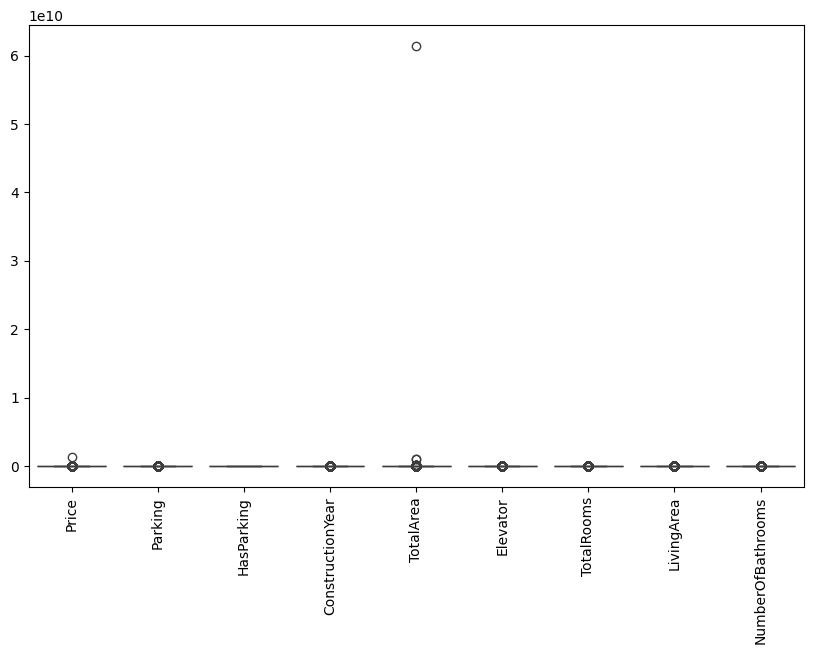

In [7]:
#check outliers boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()
